<a href="https://colab.research.google.com/github/cwf2/dices-examples/blob/main/colab/Quickstart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DICES Colab Quickstart

This notebook is intended to showcase basic operations with `dices-client`, with minimal prose explanation. To try it out in Colab, click "Runtime" -> "Run all". For more verbose tutorials, see https://github.com/cwf2/dices-examples.

## Install DICES client

In [1]:
%pip install git+https://github.com/cwf2/dices-client.git

  Cloning https://github.com/cwf2/dices-client.git to /tmp/pip-req-build-eat3gelt
  Running command git clone --filter=blob:none --quiet https://github.com/cwf2/dices-client.git /tmp/pip-req-build-eat3gelt
  Resolved https://github.com/cwf2/dices-client.git to commit 4a2609b7edb52f5134df44d66a62dee11b6a40ea
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for dices-client: filename=dices_client-0.0.2-py3-none-any.whl size=27527 sha256=6ca7ca3c868421934cab77f9fae5968cd477b0f357e41aed957c923614ea1e70
  Stored in directory: /tmp/pip-ephem-wheel-cache-h3_cp0an/wheels/49/f0/b2/ebec40e9d655480ce1013e131db773b3bdfc6066bf2a732fa7
Successfully built dices-client


# Working with speech data

In [2]:
from dicesapi import DicesAPI

# instantiate connection to DICES
api = DicesAPI()

# download speeches where Thetis is the speaker
speeches = api.getSpeeches(spkr_inst_name="Thetis")
print(f"Found {len(speeches)} speeches")

# filter
grc = speeches.filterBy("lang", "greek")
print(f" - {len(grc)} Greek speeches")

lat = speeches.filterBy("lang", "latin")
print(f" - {len(lat)} Latin speeches")
print()

# iterate over all speeches in a group
print("Latin speeches:")

for speech in lat:
    print(speech)
print()

# Speech record attributes
speech = lat[0]
print("Attributes of", speech)
print("- Author:", speech.work.author.name)
print("- Title:", speech.work.title)
print("- First line:", speech.l_fi)
print("- Last line:", speech.l_la)
print("- Speaker(s):", speech.getSpkrString())
print("- Addressee(s):", speech.getAddrString())
print("- Speech cluster:", speech.cluster)
print("- Turn in conversation:", speech.part)
print("- Level of embeddedness:", speech.level)
print("- Language:", speech.lang)
print("- Perseus URN:", speech.urn)
print("- DICES persistent ID:", speech.public_id)

Found 27 speeches
 - 18 Greek speeches
 - 9 Latin speeches

Latin speeches:
<Speech 5052: Metamorphoses 11.263-11.263>
<Speech 2766: Achilleid 1.31-1.51>
<Speech 7640: Achilleid 1.61-1.76>
<Speech 5B3A: Achilleid 1.127-1.141>
<Speech 7B97: Achilleid 1.252-1.274>
<Speech 6205: Achilleid 1.319-1.322>
<Speech E131: Achilleid 1.339-1.342>
<Speech 6832: Achilleid 1.350-1.362>
<Speech 8196: Achilleid 1.384-1.396>

Attributes of <Speech 5052: Metamorphoses 11.263-11.263>
- Author: Ovid
- Title: Metamorphoses
- First line: 11.263
- Last line: 11.263
- Speaker(s): Thetis
- Addressee(s): Peleus
- Speech cluster: <SpeechCluster 3B52: Metamorphoses 11.263 ff.>
- Turn in conversation: 1
- Level of embeddedness: 0
- Language: latin
- Perseus URN: urn:cts:latinLit:phi0959.phi006.perseus-lat2:11.263-11.263
- DICES persistent ID: 5052


## Sidebar: Using Pandas for tabular data

In [3]:
import pandas as pd

# Create an empty list to hold rows
rows = []

# iterate over all speeches
for speech in speeches:

    # define each row as a dict of labels, values
    row = {
        "language": speech.lang,
        "author": speech.work.author.name,
        "title": speech.work.title,
        "first line": speech.l_fi,
        "last line": speech.l_la,
        "speaker": speech.getSpkrString(),
        "addressee": speech.getAddrString(),
        "turn": speech.part,
    }
    # add to list
    rows.append(row)

# convert list of dicts to data frame
df = pd.DataFrame(rows)

# show the table
display(df)

,language,author,title,first line,last line,speaker,addressee,turn
0,greek,Apollonius,Argonautica,4.834,4.841,Thetis,Hera,2
1,greek,Apollonius,Argonautica,4.856,4.864,Thetis,Peleus,1
2,greek,Homer,Iliad,1.362,1.363,Thetis,Achilles,2
3,greek,Homer,Iliad,1.414,1.427,Thetis,Achilles,4
4,greek,Homer,Iliad,1.503,1.510,Thetis,Zeus,1
5,greek,Homer,Iliad,1.514,1.516,Thetis,Zeus,2
6,greek,Homer,Iliad,18.52,18.64,Thetis,Nereids,1
7,greek,Homer,Iliad,18.73,18.77,Thetis,Achilles,1
8,greek,Homer,Iliad,18.95,18.96,Thetis,Achilles,3
9,greek,Homer,Iliad,18.128,18.137,Thetis,Achilles,5


### Exporting tables from Pandas

In [4]:
# export as Excel file
df.to_excel("speeches.xlsx", index=False)

# download from Colab
from google.colab import files
files.download("speeches.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Data analysis with Pandas

While Pandas makes it easy to export tabular data to Excel, it also permits a lot of spreadsheet-like operations within Python.

In [5]:
# How many speeches in each language?
print("Speeches per language")
df.language.value_counts()

Speeches per language


,count
language,
greek,18
latin,9


<Axes: ylabel='addressee'>

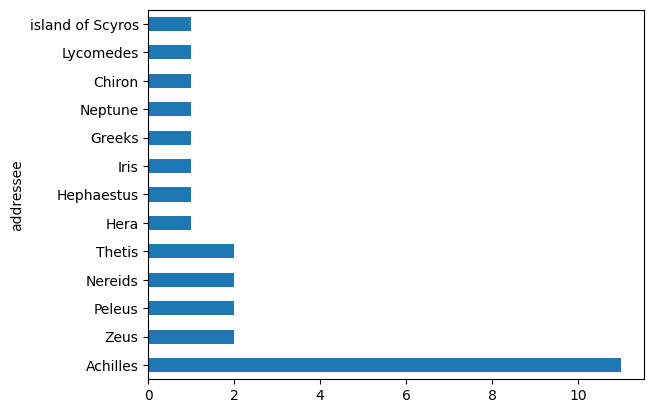

In [6]:
# How many speeches per addresse?
df["addressee"].value_counts().plot.barh()

<Axes: ylabel='addressee'>

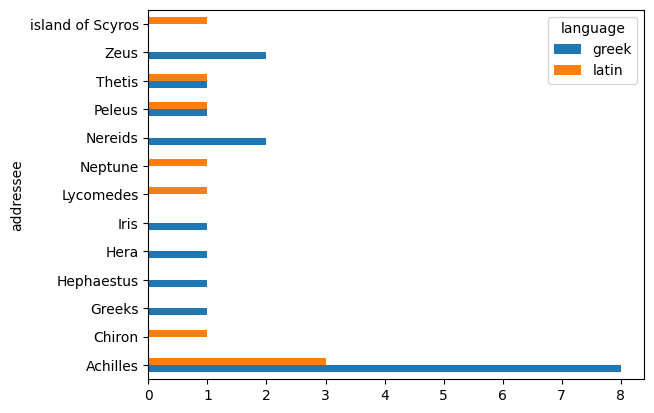

In [7]:
# How many speeches per addressee, broken down by language?
pd.crosstab(df["addressee"], df["language"]).plot.barh()

## Characters and CharacterInstances

DICES distinguishes characters' core identity from *instances* that occur in specific contexts, sometimes with changed attributes. For example, in the *Odyssey*, Tiresias is dead, while in the *Thebaid* he's alive.

The DICES `Character` **Tiresias** appears in the context of the *Odyssey* as `CharacterInstance` **ghost of Tiresias**, and in the *Thebaid* as `CharacterInstance` **Tiresias**.

Speakers and addressees in Speech records are all CharacterInstances.
 - Anonymous and collective speakers/addressees have no underlying Character.

In [8]:
# Query DICES for Characters called "Tiresias"
characters = api.getCharacters(name="Tiresias")
print(f"found {len(characters)} characters.")

for char in characters:
    print(char)
print()

# Query DICES for CharacterInstances of Tiresias
instances = api.getInstances(char_name="Tiresias")
print(f"found {len(instances)} instances.")

# Make a table of instances:
# start with empty list of rows
rows = []

# iterate over instances
for instance in instances:
    # add row
    rows.append({
        "char id": instance.char.public_id,
        "char name": instance.char.name,
        "inst id": instance.public_id,
        "inst name": instance.name,
        "inst gender": instance.gender,
        "state change": instance.changed,
        "context": instance.context,
    })

# convert list of dicts to data frame
df = pd.DataFrame(rows)

# export as csv
df.to_csv("instances.csv", index=False)

# show the table
display(df)

found 1 characters.
<Character 6266: Tiresias>

found 6 instances.


,char id,char name,inst id,inst name,inst gender,state change,context
0,6266,Tiresias,E788,Tiresias,male,none,Ovid Metamorphoses
1,6266,Tiresias,F53C,Tiresias,male,none,Statius Thebaid
2,6266,Tiresias,4E60,Tiresias,male,none,Nonnus Dionysiaca
3,6266,Tiresias,7527,Tiresias,male,none,Theocritus Idylls
4,6266,Tiresias,468E,Tiresias-woman,female,gender,Ovid Metamorphoses
5,6266,Tiresias,9CF9,ghost of Tiresias,male,death,Homer Odyssey


### Which characters appear in the most poems?

<Axes: xlabel='char name'>

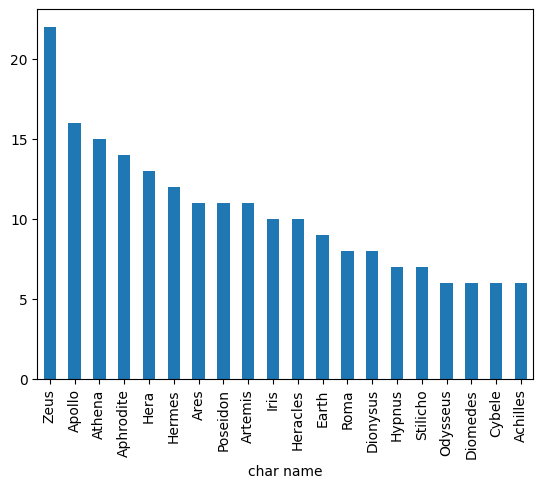

In [9]:
# download all character instances in DICES
instances = api.getInstances()

# generate a Pandas data frame
# start with empty list of rows
rows = []

# iterate over all instances
for instance in instances:
    # skip anonymous instances
    if instance.char is None:
        continue

    # add row
    rows.append({
        "char id": instance.char.public_id,
        "char name": instance.char.name,
        "inst id": instance.public_id,
        "inst name": instance.name,
        "inst gender": instance.gender,
        "state change": instance.changed,
        "context": instance.context,
    })

# convert list of dicts to data frame
inst_df = pd.DataFrame(rows)

# cross-tabulate character names and contexts
char_in_context = pd.crosstab(inst_df["char name"], inst_df["context"])

# count non-zero columns
context_tally = char_in_context.gt(0).sum(axis=1).rename("count")

# sort and take top ten
context_tally.sort_values(ascending=False).head(20).plot.bar()
